# Confiabilidad y Riesgo

**Programa:** Maestría en Ingeniería Eléctrica <br>
**Profesor:** Sebastián Aguirre Vargas <br>
**Institución:** Universidad Tecnológica de Pereira <br>
**Año:** 2026 <br>

# PCA con datos no normalizados y datos normalizados

Este notebook compara dos aplicaciones del PCA sobre el mismo conjunto de datos:

1. PCA con datos centrados, pero conservando su escala original.
2. PCA con datos normalizados mediante valores Z.

En ambos casos se utiliza `DataFrame.cov()` para la matriz de covarianzas y `numpy.linalg.eigh()` para calcular los valores y vectores propios.

## Generar Datos Multivariados Sintéticos

Crear un conjunto de datos multivariados sintéticos que simule un escenario real, permitiendo una base sólida para el análisis PCA y la demostración de sus conceptos.


# Sección A — PCA con datos no normalizados

En esta sección solamente se resta la media. Las variables conservan sus unidades y escalas originales.

1. Centrar los datos.
2. Calcular la matriz de covarianzas con `DataFrame.cov()`.
3. Obtener y ordenar los valores y vectores propios.
4. Proyectar los datos sobre los componentes principales.

In [ ]:
import numpy as np
import pandas as pd

# Crear 1000 observaciones sintéticas reproducibles
n_samples = 1000
rng = np.random.default_rng(seed=42)

# Generar valores aleatorios positivos para el radio y la altura
r = rng.uniform(1, 10, n_samples)
h = rng.uniform(1, 10, n_samples)

# Calcular las áreas y el volumen del cilindro
df = pd.DataFrame({"r": r, "h": h})
df["Ab"] = np.pi * df["r"]**2
df["AL"] = 2 * np.pi * df["r"] * df["h"]
df["AT"] = 2 * np.pi * df["r"]**2 + 2 * np.pi * df["r"] * df["h"]
df["V"] = np.pi * df["r"]**2 * df["h"]

print(f"Datos sintéticos creados: {df.shape[0]} observaciones y {df.shape[1]} variables.")
df.head()

Datos sintéticos creados: 1000 observaciones y 6 variables.


,r,h,Ab,AL,AT,V
0,7.965604,1.558568,199.336737,78.005343,476.678816,310.679851
1,4.949906,5.124358,76.973949,159.373574,313.321472,394.442101
2,8.727381,2.161271,239.286266,118.514898,597.087429,517.162351
3,7.276312,2.370940,166.330744,108.395645,441.057132,394.360279
4,1.847596,6.690545,10.724177,77.669128,99.117481,71.750590


## 1. Centrar los datos

Se calcula la media de cada columna y se resta de los datos originales:

$$X_c = X - \bar{X}$$

In [ ]:
# Calcular el vector de medias


# Centrar cada variable


print("Vector de medias:")
print(mean_vector.round(4))
print("\nPrimeras filas de los datos centrados:")
print(df_centered.head())
print("\nMedia de los datos centrados:")
print(df_centered.mean().round(10))

Vector de medias:
r       5.4746
h       5.5765
Ab    115.7713
AL    191.8887
AT    423.4314
V     646.4378
dtype: float64

Primeras filas de los datos centrados:
          r         h          Ab          AL          AT           V
0  2.491004 -4.017892   83.565392 -113.883392   53.247392 -335.757994
1 -0.524695 -0.452102  -38.797396  -32.515161 -110.109952 -251.995744
2  3.252781 -3.415190  123.514921  -73.373836  173.656005 -129.275495
3  1.801712 -3.205520   50.559399  -83.493090   17.625708 -252.077566
4 -3.627004  1.114085 -105.047168 -114.219606 -324.313943 -574.687255

Media de los datos centrados:
r    -0.0
h    -0.0
Ab   -0.0
AL    0.0
AT   -0.0
V    -0.0
dtype: float64


## 2. Matriz de covarianzas, valores propios y vectores propios

La matriz de covarianzas se obtiene directamente con pandas. Como esta matriz es simétrica, `np.linalg.eigh()` permite calcular sus valores y vectores propios.

In [ ]:
# Matriz de covarianzas de los datos centrados


# Valores propios y vectores propios
#Calculo
print(eigenvalues)
# Ordenar de mayor a menor valor propio
order = np.argsort(eigenvalues)[::-1]
print(order)
eigenvalues = eigenvalues[order]
print(eigenvalues)
eigenvectors = eigenvectors[:, order]

print("Matriz de covarianzas:")
print(cov_matrix.round(4))


[-1.88763721e-12  4.81881791e-02  1.32993986e+00  1.39259808e+03
  9.94446783e+03  5.19723304e+05]
[5 4 3 2 1 0]
[ 5.19723304e+05  9.94446783e+03  1.39259808e+03  1.32993986e+00
  4.81881791e-02 -1.88763721e-12]
Matriz de covarianzas:
            r         h          Ab          AL           AT            V
r      6.8868    0.0112    237.0094    242.6041     716.6229    1333.4675
h      0.0112    6.7813      0.8444    230.4859     232.1747     777.4933
Ab   237.0094    0.8444   8512.9335   8399.3509   25425.2180   48119.1086
AL   242.6041  230.4859   8399.3509  18257.1626   35055.8645   83791.7093
AT   716.6229  232.1747  25425.2180  35055.8645   85906.3005  180029.9265
V   1333.4675  777.4933  48119.1086  83791.7093  180029.9265  418371.6837


In [ ]:
# Varianza explicada


print(cumulative_variance)

component_names = [f"PC{i}" for i in range(1, len(df.columns) + 1)] #define el numero de componentes principales según el número de columnas en el DataFrame

eigenvalues_table = pd.DataFrame({
    "Componente": component_names,
    "Valor propio": eigenvalues,
    "Varianza explicada (%)": explained_variance * 100,
    "Varianza acumulada (%)": cumulative_variance * 100,
})

eigenvectors_df = pd.DataFrame(
    eigenvectors,
    index=df.columns,
    columns=component_names,
)

print("\nValores propios y varianza explicada:")
print(eigenvalues_table.round(6))
print("\nVectores propios (cada columna es un componente):")
print(eigenvectors_df.round(6))


[0.97864948 0.99737511 0.9999974  0.99999991 1.         1.        ]

Valores propios y varianza explicada:
  Componente   Valor propio  Varianza explicada (%)  Varianza acumulada (%)
0        PC1  519723.304375               97.864948               97.864948
1        PC2    9944.467830                1.872563               99.737511
2        PC3    1392.598084                0.262229               99.999740
3        PC4       1.329940                0.000250               99.999991
4        PC5       0.048188                0.000009              100.000000
5        PC6      -0.000000               -0.000000              100.000000

Vectores propios (cada columna es un componente):
         PC1       PC2       PC3       PC4       PC5       PC6
r  -0.002972 -0.014590  0.001282  0.317398  0.948175  0.000000
h  -0.001595  0.014725  0.038872 -0.947409  0.317310  0.000000
Ab -0.106785 -0.500086 -0.267360 -0.019000 -0.001308  0.816497
AL -0.178917  0.243280  0.860661  0.036032 -0.010042  0.40

## 3. Scree plot

El gráfico presenta la varianza explicada por cada valor propio y la varianza acumulada.

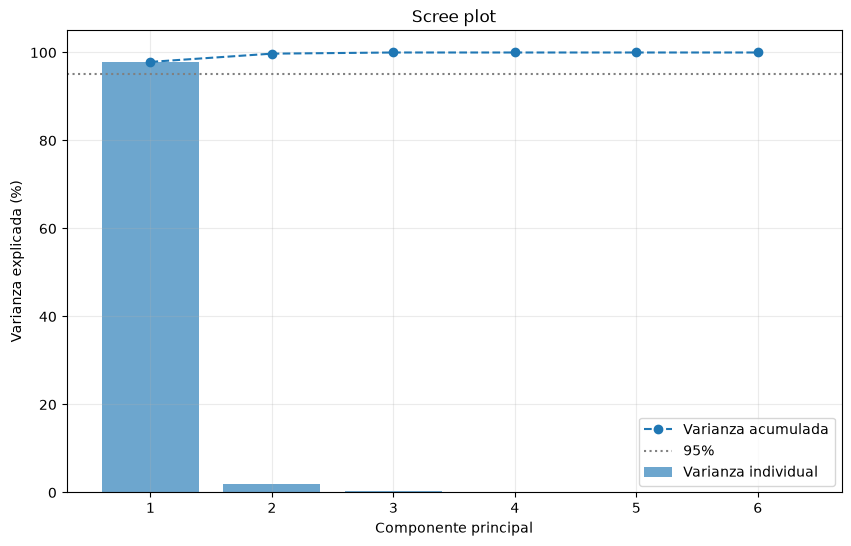

In [ ]:
import matplotlib.pyplot as plt

components = np.arange(1, len(eigenvalues) + 1)

plt.figure(figsize=(10, 6))
plt.bar(components, explained_variance * 100, alpha=0.65, label="Varianza individual")
plt.plot(components, cumulative_variance * 100, "o--", label="Varianza acumulada")
plt.axhline(95, color="gray", linestyle=":", label="95%")
plt.xticks(components)
plt.xlabel("Componente principal")
plt.ylabel("Varianza explicada (%)")
plt.title("Scree plot")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

### Interpretación del scree plot

PC1 explica aproximadamente el **97.86%** de la varianza. PC2 aporta cerca del **1.87%**, por lo que los dos primeros componentes acumulan aproximadamente el **99.74%**.

El último valor propio es prácticamente cero porque existe una dependencia lineal exacta: $AT = 2Ab + AL$.

In [ ]:
# Proyectar los datos centrados sobre los vectores propios
pca_data = pd.DataFrame(
    df_centered.values @ eigenvectors,
    columns=component_names,
    index=df.index,
)
print("\nPrimeras filas proyectadas:")
print(pca_data.head())


Primeras filas proyectadas:
          PC1         PC2        PC3       PC4       PC5           PC6
0  291.337506 -224.943034  -8.169514 -0.045617  0.105317  4.397724e-12
1  278.927216    8.486225  17.769627  0.909746  0.122910  7.206248e-13
2   47.586449 -255.452150  -3.128225 -0.620597 -0.139072 -1.835884e-12
3  228.442278 -145.386436  -8.442120  0.470837  0.232878  6.613559e-12
4  673.778787   73.365163 -13.310123 -1.713722  0.007172  7.105633e-12


## 4. Proyección sobre PC1 y PC2

La nueva matriz de datos se obtiene multiplicando los datos centrados por la matriz de vectores propios.

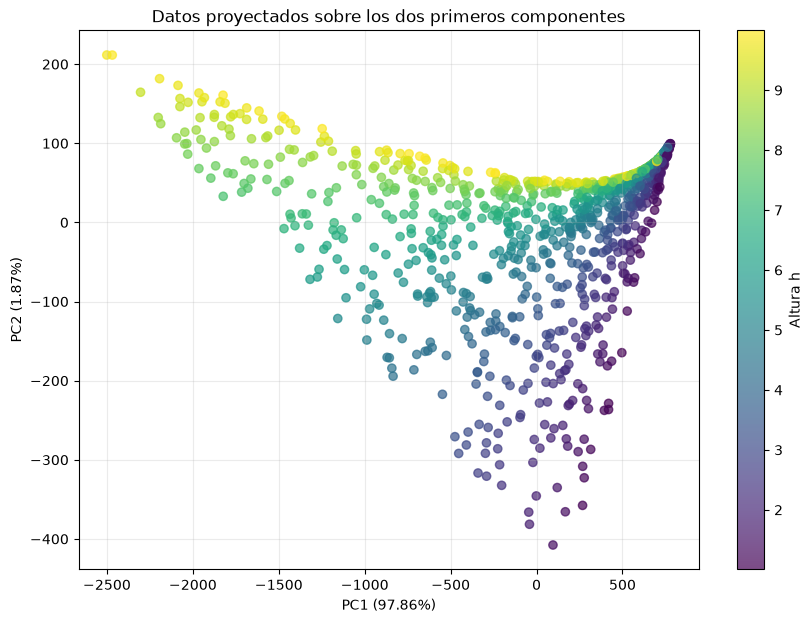

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(
    pca_data["PC1"],
    pca_data["PC2"],
    c=df["h"],
    cmap="viridis",
    alpha=0.7,
)
plt.xlabel(f"PC1 ({explained_variance[0] * 100:.2f}%)")
plt.ylabel(f"PC2 ({explained_variance[1] * 100:.2f}%)")
plt.title("Datos proyectados sobre los dos primeros componentes")
plt.colorbar(label="Altura h")
plt.grid(alpha=0.25)
plt.show()

### Interpretación

El PCA basado en la matriz de covarianzas conserva la escala original de las variables. Por eso el volumen `V` y las áreas, que tienen mayor varianza, dominan el primer componente.

Los vectores propios mostrados en la tabla definen las nuevas direcciones del espacio y `pca_data` contiene las observaciones proyectadas sobre esas direcciones.

# Sección B — PCA con datos normalizados

Para evitar que las variables de mayor escala dominen el PCA, se utiliza la normalización mediante valores Z:

$$Z = \frac{X - \bar{X}}{s}$$

Cada variable normalizada tiene media aproximadamente cero y desviación estándar igual a uno.

In [ ]:
# Normalización Z usando operaciones de pandas


print("Media de los datos normalizados:")
print(df_normalized.mean().round(10))
print("\nDesviación estándar de los datos normalizados:")
print(df_normalized.std().round(4))
print("\nPrimeras filas:")
print(df_normalized.head())

Media de los datos normalizados:
r    -0.0
h    -0.0
Ab   -0.0
AL    0.0
AT   -0.0
V    -0.0
dtype: float64

Desviación estándar de los datos normalizados:
r     1.0
h     1.0
Ab    1.0
AL    1.0
AT    1.0
V     1.0
dtype: float64

Primeras filas:
          r         h        Ab        AL        AT         V
0  0.949217 -1.542920  0.905705 -0.842837  0.181671 -0.519093
1 -0.199939 -0.173613 -0.420497 -0.240641 -0.375677 -0.389594
2  1.239499 -1.311475  1.338689 -0.543031  0.592485 -0.199864
3  0.686557 -1.230959  0.547977 -0.617922  0.060136 -0.389720
4 -1.382100  0.427822 -1.138531 -0.845326 -1.106504 -0.888486


## 5. Matriz de covarianzas y pares propios de los datos normalizados

Se repite el cálculo manual del PCA. En los datos normalizados, la matriz de covarianzas es equivalente a la matriz de correlaciones de las variables originales.

In [ ]:
# Matriz de covarianzas de los datos normalizados


# Valores y vectores propios
normalized_eigenvalues, normalized_eigenvectors = np.linalg.eigh(
    normalized_cov_matrix.values
)

# Ordenar de mayor a menor valor propio
normalized_order = np.argsort(normalized_eigenvalues)[::-1]
normalized_eigenvalues = normalized_eigenvalues[normalized_order]
normalized_eigenvectors = normalized_eigenvectors[:, normalized_order]
normalized_eigenvalues = np.maximum(normalized_eigenvalues, 0)

# Varianza explicada
normalized_explained_variance = (
    normalized_eigenvalues / normalized_eigenvalues.sum()
)
normalized_cumulative_variance = np.cumsum(normalized_explained_variance)
normalized_n_components_95 = (
    np.argmax(normalized_cumulative_variance >= 0.95) + 1
)

normalized_component_names = [
    f"PC{i}" for i in range(1, len(df.columns) + 1)
]

normalized_eigenvalues_table = pd.DataFrame({
    "Componente": normalized_component_names,
    "Valor propio": normalized_eigenvalues,
    "Varianza explicada (%)": normalized_explained_variance * 100,
    "Varianza acumulada (%)": normalized_cumulative_variance * 100,
})

normalized_eigenvectors_df = pd.DataFrame(
    normalized_eigenvectors,
    index=df.columns,
    columns=normalized_component_names,
)

# Proyección de los datos normalizados
normalized_pca_data = pd.DataFrame(
    df_normalized.values @ normalized_eigenvectors,
    columns=normalized_component_names,
    index=df.index,
)

print("Matriz de covarianzas de los datos normalizados:")
print(normalized_cov_matrix.round(4))
print("\nValores propios y varianza explicada:")
print(normalized_eigenvalues_table.round(6))
print("\nVectores propios:")
print(normalized_eigenvectors_df.round(6))
print(
    "\nComponentes necesarios para explicar al menos el 95%: "
    f"{normalized_n_components_95}"
)
print("\nPrimeras filas proyectadas:")
print(normalized_pca_data.head())

Matriz de covarianzas de los datos normalizados:
         r       h      Ab      AL      AT       V
r   1.0000  0.0016  0.9789  0.6842  0.9317  0.7856
h   0.0016  1.0000  0.0035  0.6550  0.3042  0.4616
Ab  0.9789  0.0035  1.0000  0.6737  0.9402  0.8063
AL  0.6842  0.6550  0.6737  1.0000  0.8852  0.9587
AT  0.9317  0.3042  0.9402  0.8852  1.0000  0.9496
V   0.7856  0.4616  0.8063  0.9587  0.9496  1.0000

Valores propios y varianza explicada:
  Componente  Valor propio  Varianza explicada (%)  Varianza acumulada (%)
0        PC1      4.558827               75.980458               75.980458
1        PC2      1.296632               21.610532               97.590990
2        PC3      0.109769                1.829489               99.420479
3        PC4      0.032861                0.547683               99.968162
4        PC5      0.001910                0.031838              100.000000
5        PC6      0.000000                0.000000              100.000000

Vectores propios:
         PC

## 6. Scree plot y proyección de los datos normalizados

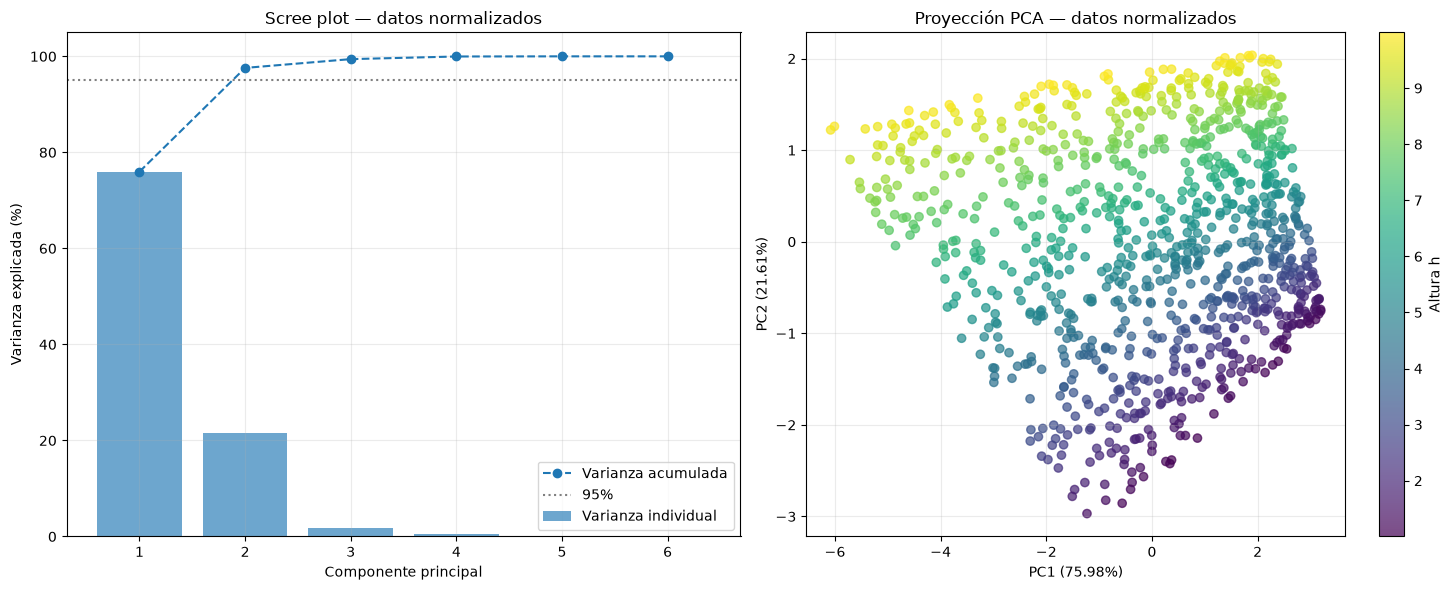

In [ ]:
normalized_components = np.arange(1, len(normalized_eigenvalues) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].bar(
    normalized_components,
    normalized_explained_variance * 100,
    alpha=0.65,
    label="Varianza individual",
)
axes[0].plot(
    normalized_components,
    normalized_cumulative_variance * 100,
    "o--",
    label="Varianza acumulada",
)
axes[0].axhline(95, color="gray", linestyle=":", label="95%")
axes[0].set_xticks(normalized_components)
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Varianza explicada (%)")
axes[0].set_title("Scree plot — datos normalizados")
axes[0].grid(alpha=0.25)
axes[0].legend()

scatter = axes[1].scatter(
    normalized_pca_data["PC1"],
    normalized_pca_data["PC2"],
    c=df["h"],
    cmap="viridis",
    alpha=0.7,
)
axes[1].set_xlabel(
    f"PC1 ({normalized_explained_variance[0] * 100:.2f}%)"
)
axes[1].set_ylabel(
    f"PC2 ({normalized_explained_variance[1] * 100:.2f}%)"
)
axes[1].set_title("Proyección PCA — datos normalizados")
axes[1].grid(alpha=0.25)
fig.colorbar(scatter, ax=axes[1], label="Altura h")

plt.tight_layout()
plt.show()

## 7. Comparación de los dos análisis

- **Datos no normalizados:** PC1 explica aproximadamente el **97.86%**. El volumen y las áreas dominan porque tienen una escala mayor.
- **Datos normalizados:** PC1 explica aproximadamente el **75.98%** y PC2 el **21.61%**; juntos acumulan cerca del **97.59%**.

La normalización distribuye mejor la influencia de `r`, `h`, `Ab`, `AL`, `AT` y `V`. En ambos análisis aparece un valor propio prácticamente nulo debido a la dependencia lineal $AT = 2Ab + AL$.